# 01 — MDP Formulation
**Week 3 | RL Fundamentals**

A **Markov Decision Process** (MDP) is defined by the 5-tuple:

$$M = (\mathcal{S},\; \mathcal{A},\; \mathcal{R},\; \mathcal{T},\; \gamma)$$

| Symbol | Meaning |
|---|---|
| S | State space |
| A | Action space |
| R(s,a,s') | Reward function |
| T(s,a,s') | Transition function P(s'|s,a) |
| γ ∈ [0,1) | Discount factor |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. Constructing a Tiny MDP by Hand
A recycling robot (from Sutton & Barto, Example 3.3):  
- **States**: {high battery, low battery}  
- **Actions**: {search, wait, recharge}  
- **Goal**: maximise cans collected

In [2]:
# States
S = ['high', 'low']
s_idx = {s: i for i, s in enumerate(S)}

# Actions (not all available in every state but we'll handle that via masks)
A = ['search', 'wait', 'recharge']
a_idx = {a: i for i, a in enumerate(A)}

# Transition tensor: T[s, a, s'] = P(s'|s,a)
# and Reward matrix:  R[s, a] = expected reward
alpha = 0.9   # P(stay high | high, search)
beta  = 0.4   # P(stay low  | low,  search)
r_search_high = 4.0
r_search_low  = 2.0
r_wait        = 1.0

T = np.zeros((2, 3, 2))   # (states, actions, next_states)
R = np.full((2, 3), -np.inf)  # -inf for illegal actions

# From HIGH
T[0, 0, 0] = alpha;    T[0, 0, 1] = 1 - alpha;  R[0, 0] = r_search_high  # search
T[0, 1, 0] = 1.0;                                R[0, 1] = r_wait         # wait
# recharge not available from high

# From LOW
T[1, 0, 0] = 1-beta;   T[1, 0, 1] = beta;        R[1, 0] = r_search_low   # search
T[1, 1, 1] = 1.0;                                 R[1, 1] = r_wait         # wait
T[1, 2, 0] = 1.0;                                 R[1, 2] = 0.0            # recharge

print("Transition tensor shape:", T.shape, "  (states × actions × next_states)")
print("\nReward matrix R[s,a]:")
for i, s in enumerate(S):
    for j, a in enumerate(A):
        r = R[i, j]
        print(f"  R[{s},{a}] = {r if r != -np.inf else 'N/A'}")

Transition tensor shape: (2, 3, 2)   (states × actions × next_states)

Reward matrix R[s,a]:
  R[high,search] = 4.0
  R[high,wait] = 1.0
  R[high,recharge] = N/A
  R[low,search] = 2.0
  R[low,wait] = 1.0
  R[low,recharge] = 0.0


## 2. Simulate One Episode Under a Random Policy

In [3]:
def valid_actions(s):
    if s == 0:  return [0, 1]        # high: search, wait
    else:       return [0, 1, 2]     # low:  search, wait, recharge

def step(s, a):
    next_s = np.random.choice(2, p=T[s, a])
    r = R[s, a]
    return next_s, r

def simulate_episode(start=0, n_steps=20, gamma=0.95):
    s = start
    trajectory = []
    for t in range(n_steps):
        a = np.random.choice(valid_actions(s))
        next_s, r = step(s, a)
        trajectory.append({'t': t, 'state': S[s], 'action': A[a], 'reward': r, 'next': S[next_s]})
        s = next_s
    return trajectory

traj = simulate_episode()
print(f"{'t':>3}  {'State':<8} {'Action':<10} {'Reward':>7}  {'Next':>8}")
print("-" * 45)
for step_ in traj[:10]:
    print(f"{step_['t']:>3}  {step_['state']:<8} {step_['action']:<10} {step_['reward']:>7.1f}  {step_['next']:>8}")

  t  State    Action      Reward      Next
---------------------------------------------
  0  high     search         4.0      high
  1  high     search         4.0      high
  2  high     wait           1.0      high
  3  high     wait           1.0      high
  4  high     search         4.0      high
  5  high     search         4.0       low
  6  low      recharge       0.0      high
  7  high     wait           1.0      high
  8  high     search         4.0      high
  9  high     wait           1.0      high


## 3. Real-World MDP Formulations
Practice framing problems as MDPs before coding them.

In [4]:
problems = {
    "Taxi Driver": {
        "States":   "(row, col, passenger_loc, destination) — 500 states",
        "Actions":  "N, S, E, W, Pickup, Dropoff",
        "Reward":   "-1 per step, +20 for delivery, -10 illegal pickup/dropoff",
        "Terminal": "After successful dropoff",
        "gamma":    0.99,
    },
    "CartPole": {
        "States":   "(cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4",
        "Actions":  "Push left (0) or Push right (1)",
        "Reward":   "+1 for every timestep the pole stays upright",
        "Terminal": "Pole falls >15° or cart moves >2.4 from centre",
        "gamma":    1.0,
    },
    "Trading Agent": {
        "States":   "(price_history, holdings, cash, technical_indicators)",
        "Actions":  "Buy / Sell / Hold (continuous or discrete)",
        "Reward":   "Change in portfolio value or Sharpe ratio",
        "Terminal": "End of trading day / time horizon reached",
        "gamma":    0.99,
    },
}

for name, mdp in problems.items():
    print(f"\n=== {name} ===")
    for k, v in mdp.items():
        print(f"  {k:<10}: {v}")


=== Taxi Driver ===
  States    : (row, col, passenger_loc, destination) — 500 states
  Actions   : N, S, E, W, Pickup, Dropoff
  Reward    : -1 per step, +20 for delivery, -10 illegal pickup/dropoff
  Terminal  : After successful dropoff
  gamma     : 0.99

=== CartPole ===
  States    : (cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4
  Actions   : Push left (0) or Push right (1)
  Reward    : +1 for every timestep the pole stays upright
  Terminal  : Pole falls >15° or cart moves >2.4 from centre
  gamma     : 1.0

=== Trading Agent ===
  States    : (price_history, holdings, cash, technical_indicators)
  Actions   : Buy / Sell / Hold (continuous or discrete)
  Reward    : Change in portfolio value or Sharpe ratio
  Terminal  : End of trading day / time horizon reached
  gamma     : 0.99


## ✅ Exercises
1. Formalise a **Frozen Lake 4×4** as an MDP. How many states? How many actions? What are the terminal states?
2. Pick a board game you know (noughts & crosses, connect 4). Define S, A, R, and T for it.
3. **Challenge**: simulate 1000 episodes of the recycling robot under the policy 'always search'. Plot the distribution of total undiscounted reward per episode.

## Question 1.


States: 16 cells in total (4x4 grid). Each cell can be Start, Frozen, Hole, or Goal.

Actions: 4 actions- Up, Down, Left, Right.

Terminal states: Any Hole cell, or the Goal cell. In the standard map there are 4 holes and 1 goal, so 5 terminal states.

Reward: +1 if you reach the Goal. 0 for everything else, even if you fall in a hole (episode just ends).

Transition: If slippery mode is on, the action you pick doesn't always work - there's a chance you slide sideways instead. If not slippery, it just moves where you tell it to.

Gamma: Usually around 0.99 since it's an episodic task and reaching the goal still matters even if it takes a while.

## Question 2.

States: board is 7 columns and 6 rows so 42 cells, each one empty or has a red/yellow piece. theoretically could be 3^42 combos but most of those can't actually happen since pieces just stack on top of each other in a column, they can't float in air. so the real number of states is way less but still really huge, ppl say its around 4.5 trillion possible positions.

Actions: just drop your piece in one of 7 columns. but if a column is already full you cant pick it, so the actions you can take change depending on the state, same logic as the high/low battery example.

Terminal states: when someone gets 4 in a row (could be straight, up down, or diagonal) or when the whole board is full and nobody won (draw).

Reward: +1 if you win, -1 if you lose, 0 for draw, 0 for every other move while the game is still going.

Transition: your move is deterministic, the piece just falls to the lowest empty spot in whichever column you chose. opponent's move we can just count as part of the environment, like it could be random or could follow some strategy, depends what we're trying to train against.

Gamma: just use 1.0 since the game ends in finite moves and theres no real need to discount stuff here.

## Question 3.


In [8]:
def simulate_episode_always_search(start=0, n_steps=20):
    s = start
    total_reward = 0.0
    for t in range(n_steps):
        a = 0  # 'search' is action index 0, valid from both high and low
        next_s, r = step(s, a)
        total_reward += r
        s = next_s
    return total_reward

# quick sanity check - run it once and print
test_reward = simulate_episode_always_search()
print("One test episode total reward:", test_reward)

One test episode total reward: 76.0


In [9]:
n_episodes = 1000
episode_rewards = [simulate_episode_always_search() for _ in range(n_episodes)]

print(f"Mean total reward: {np.mean(episode_rewards):.2f}")
print(f"Std  total reward: {np.std(episode_rewards):.2f}")
print(f"Min: {np.min(episode_rewards):.2f}, Max: {np.max(episode_rewards):.2f}")

Mean total reward: 74.71
Std  total reward: 3.93
Min: 60.00, Max: 80.00


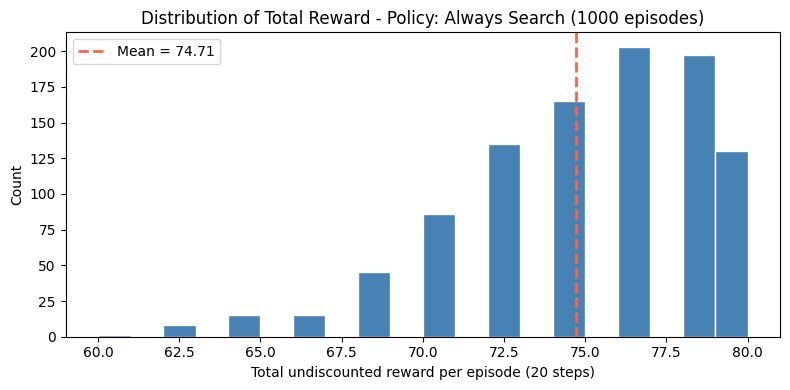

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(episode_rewards, bins=20, color='steelblue', edgecolor='white')
plt.axvline(np.mean(episode_rewards), color='tomato', linestyle='--', linewidth=2, label=f'Mean = {np.mean(episode_rewards):.2f}')
plt.xlabel('Total undiscounted reward per episode (20 steps)')
plt.ylabel('Count')
plt.title('Distribution of Total Reward - Policy: Always Search (1000 episodes)')
plt.legend()
plt.tight_layout(); plt.show()